In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from lazy5.inspect import get_attrs_dset
import os
from crikit.preprocess.denoise import SVDDecompose, SVDRecompose
from crikit.cri.kk import KramersKronig
from crikit.cri.error_correction import PhaseErrCorrectALS

In [6]:
DATA_FOLDER = "."
filename = "preprocessed_medfilter_glycerol.h5"
f = h5py.File(os.path.join(DATA_FOLDER,filename), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the shape of the extracted dataset
attrs = get_attrs_dset(filename, 'preprocessed_images/medfilter_ratio')

In [7]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe

# Select wn values between 400 and 1800
wn_mask = (wn >= 400) & (wn <= 1800)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]

In [15]:
hsi = np.load('hsi_3d.npz')['arr_0']
hsi_selected = hsi[:, :-1, indices]
nrb = np.load('nrb_3d.npz')['arr_0']
nrb_selected = nrb[:, :-1, indices]

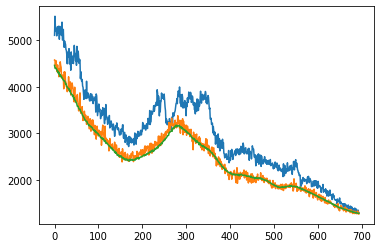

In [16]:
plt.plot( hsi_selected[60,250,:])
plt.plot( nrb_selected[60,250,:])
avg_nrb = np.average(nrb_selected, axis=(0))
plt.plot( avg_nrb[250,:])

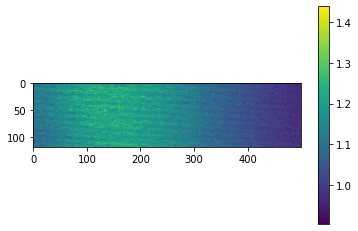

In [22]:
ratio = hsi_selected/avg_nrb
img = ratio[:,:,600]
plt.imshow(img)
plt.colorbar()


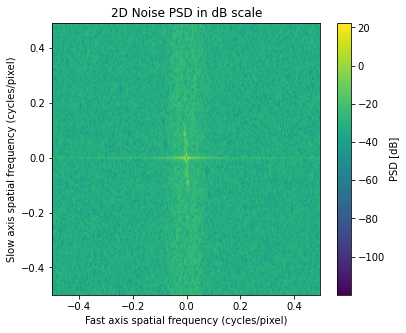

In [42]:
img = ratio[:,:,600]
def psd_via_autocorr(img):
    img = np.asarray(img, dtype=float)
    Ny, Nx = img.shape
    x = img - img.mean()

    F = np.fft.fft2(x)
    R = np.fft.ifft2(np.abs(F)**2).real
    R = np.fft.fftshift(R) / (Ny * Nx)

    PSD = np.fft.fft2(np.fft.ifftshift(R))
    PSD = np.abs(PSD).real
    PSD = np.fft.fftshift(PSD)

    fy = np.fft.fftshift(np.fft.fftfreq(Ny))
    fx = np.fft.fftshift(np.fft.fftfreq(Nx))
    return fy, fx, PSD, R

# #synthetic demo data


# np.random.seed(1)
# Ny, Nx = 128, 256
# white = np.random.normal(0, 1.0, (Ny, Nx))

# kx = np.fft.fftfreq(Nx)
# ky = np.fft.fftfreq(Ny)
# KX, KY = np.meshgrid(kx, ky)
# H = 1.0 / (1.0 + (5*KX)**2)
# FX = np.fft.fft2(white) * np.fft.fftshift(H)
# corr_x = np.fft.ifft2(FX).real

# img = corr_x

fy, fx, PSD2, R2 = psd_via_autocorr(img)

# Avoid log of zero
PSD_dB = 10 * np.log10(PSD2 + 1e-12)

plt.figure(figsize=(6,5))
plt.imshow(PSD_dB,
           extent=[fx[0], fx[-1], fy[0], fy[-1]],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='PSD [dB]')
plt.xlabel('Fast axis spatial frequency (cycles/pixel)')
plt.ylabel('Slow axis spatial frequency (cycles/pixel)')
plt.title('2D Noise PSD in dB scale')
plt.show()


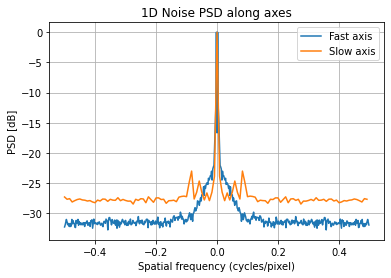

In [47]:
# Assume PSD2 is your 2D PSD, fx/fy are frequency axes
PSD_fast = PSD2.mean(axis=0)   # average over slow axis → spectrum vs fast freq
PSD_slow = PSD2.mean(axis=1)   # average over fast axis → spectrum vs slow freq

PSD_fast_dB = 10 * np.log10(PSD_fast / PSD_fast.max() + 1e-12)
PSD_slow_dB = 10 * np.log10(PSD_slow / PSD_slow.max() + 1e-12)

plt.figure(figsize=(6,4))
plt.plot(fx, PSD_fast_dB, label="Fast axis")
plt.plot(fy, PSD_slow_dB, label="Slow axis")
plt.xlabel("Spatial frequency (cycles/pixel)")
plt.ylabel("PSD [dB]")
plt.title("1D Noise PSD along axes")
plt.legend()
plt.grid(True)
plt.show()
